In [1]:
# ============================================================
# SentinelAI - Currency Agent
# Manual Grad-CAM Explainability
# ============================================================

import json
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.models as models
from torchvision import transforms
from torchvision.models import MobileNet_V2_Weights

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = False

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch      :", torch.__version__)
print("TorchVision  :", torchvision.__version__)

PyTorch      : 2.11.0+cu128
TorchVision  : 0.26.0+cu128


In [2]:
# ============================================================
# Project Paths
# ============================================================

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = CURRENT_DIR.parent.parent

DATA_DIR = CURRENT_DIR / "data"

MODEL_DIR = PROJECT_ROOT / "models" / "currency"

MODEL_PATH = MODEL_DIR / "mobilenetv2_best.pth"

CLASS_PATH = MODEL_DIR / "class_names.json"

OUTPUT_DIR = CURRENT_DIR / "gradcam_results"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Current Directory :", CURRENT_DIR)
print("Project Root      :", PROJECT_ROOT)
print("Data Directory    :", DATA_DIR)
print("Model Directory   :", MODEL_DIR)

Current Directory : c:\Users\ANKIT\Desktop\SentinelAi\datasets\currency
Project Root      : c:\Users\ANKIT\Desktop\SentinelAi
Data Directory    : c:\Users\ANKIT\Desktop\SentinelAi\datasets\currency\data
Model Directory   : c:\Users\ANKIT\Desktop\SentinelAi\models\currency


In [3]:
# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Using Device : cuda
GPU : NVIDIA GeForce RTX 2050


In [4]:
# ============================================================
# Load Class Labels
# ============================================================

with open(CLASS_PATH, "r") as f:
    class_names = json.load(f)

idx_to_class = {
    int(k): v
    for k, v in class_names.items()
}

print(idx_to_class)

{0: 'fake', 1: 'real'}


In [5]:
# ============================================================
# Load Trained MobileNetV2
# ============================================================

model = models.mobilenet_v2(
    weights=MobileNet_V2_Weights.DEFAULT
)

# Replace classifier
model.classifier[1] = nn.Linear(
    model.last_channel,
    2
)

# Load trained weights
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

# Your checkpoint is a pure state_dict
model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("✅ MobileNetV2 loaded successfully.")

# ------------------------------------------------------------
# Target Layer
# ------------------------------------------------------------

# Last convolution layer before global pooling
TARGET_LAYER = model.features[18][0]

print("\nTarget Layer:")
print(TARGET_LAYER)

✅ MobileNetV2 loaded successfully.

Target Layer:
Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [11]:
# ============================================================
# Manual Grad-CAM
# ============================================================

class ManualGradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Register hooks
        self.forward_handle = target_layer.register_forward_hook(
            self._forward_hook
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self._backward_hook
        )

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, target_class=None):

        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        score = output[:, target_class]

        score.backward(retain_graph=True)

        if self.gradients is None:
            raise RuntimeError(
                "Gradients were not captured."
            )

        if self.activations is None:
            raise RuntimeError(
                "Activations were not captured."
            )

        gradients = self.gradients
        activations = self.activations

        # Global Average Pooling
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = torch.sum(
            weights * activations,
            dim=1
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze()

        cam = cam.detach().cpu().numpy()

        cam -= cam.min()

        cam /= (cam.max() + 1e-8)

        return cam

    def remove(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


# Initialize
gradcam = ManualGradCAM(
    model=model,
    target_layer=TARGET_LAYER
)

print("✅ Manual Grad-CAM initialized")

✅ Manual Grad-CAM initialized


In [12]:
# ============================================================
# Initialize Manual Grad-CAM
# ============================================================

gradcam = ManualGradCAM(
    model=model,
    target_layer=TARGET_LAYER
)

print("✅ Manual Grad-CAM Initialized")

✅ Manual Grad-CAM Initialized


In [13]:
# ============================================================
# Image Transform
# ============================================================

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [14]:
# ============================================================
# Prediction
# ============================================================

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    tensor = transform(image)

    tensor = tensor.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    return (
        image,
        tensor,
        prediction.item(),
        confidence.item()
    )

In [16]:
# ============================================================
# Scan Dataset
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
    ".avif"
}


def scan_images(folder):

    images = []

    for file in folder.rglob("*"):

        if file.suffix.lower() in IMAGE_EXTENSIONS:
            images.append(file)

    return sorted(images)


real_images = scan_images(DATA_DIR / "real")
fake_images = scan_images(DATA_DIR / "fake")

print(f"REAL Images : {len(real_images)}")
print(f"FAKE Images : {len(fake_images)}")

REAL Images : 4937
FAKE Images : 2508


In [17]:
# ============================================================
# Select Images
# ============================================================

random.shuffle(real_images)
random.shuffle(fake_images)

correct_real = []
correct_fake = []
misclassified = []


def evaluate_images(image_list, gt_class, required=3):

    selected = []

    global misclassified

    for img_path in image_list:

        image, tensor, pred, conf = predict_image(img_path)

        if pred == gt_class:

            selected.append(
                (img_path, conf)
            )

        else:

            if len(misclassified) < 2:

                misclassified.append(
                    (
                        img_path,
                        gt_class,
                        pred,
                        conf
                    )
                )

        if len(selected) == required:
            break

    return selected


correct_real = evaluate_images(
    real_images,
    gt_class=1,
    required=3
)

correct_fake = evaluate_images(
    fake_images,
    gt_class=0,
    required=3
)

print("="*60)

print("Correct REAL :", len(correct_real))
print("Correct FAKE :", len(correct_fake))
print("Misclassified:", len(misclassified))

Correct REAL : 3
Correct FAKE : 3
Misclassified: 1


In [25]:
# ============================================================
# Heatmap
# ============================================================

def make_heatmap(cam):

    cam = np.uint8(255 * cam)

    heatmap = cv2.applyColorMap(
        cam,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    return heatmap

In [26]:
# ============================================================
# Overlay Heatmap
# ============================================================

def overlay_heatmap(image, heatmap):

    # PIL Image -> NumPy
    image = np.array(image)

    # Convert to uint8
    image = image.astype(np.uint8)

    # Resize heatmap if needed
    if heatmap.shape[:2] != image.shape[:2]:
        heatmap = cv2.resize(
            heatmap,
            (image.shape[1], image.shape[0])
        )

    # Ensure heatmap is uint8
    heatmap = heatmap.astype(np.uint8)

    overlay = cv2.addWeighted(
        image,
        0.65,
        heatmap,
        0.35,
        0
    )

    return overlay

In [27]:
# ============================================================
# Visualization
# ============================================================

def visualize(image_path,
              ground_truth,
              use_ground_truth=False):

    image, tensor, prediction, confidence = predict_image(image_path)

    if use_ground_truth:
        target_class = ground_truth
    else:
        target_class = prediction

    cam = gradcam.generate(
        tensor,
        target_class
    )

    heatmap = make_heatmap(cam)

    overlay = overlay_heatmap(
        image,
        heatmap
    )

    fig, ax = plt.subplots(
        1,
        3,
        figsize=(18,6)
    )

    ax[0].imshow(image)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(heatmap)
    ax[1].set_title("Grad-CAM")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    plt.show()

    print("="*60)

    print("Ground Truth :", idx_to_class[ground_truth])

    print("Prediction   :", idx_to_class[prediction])

    print(f"Confidence   : {confidence*100:.2f}%")

    print("\nInterpretation:")

    print("- Security Thread")

    print("- Watermark")

    print("- Gandhi Portrait")

    print("- Numerals")

    print("- Background")

    print("- Entire Note Body")

In [31]:
# ============================================================
# Visualization + Save Results
# ============================================================

def visualize_and_save(
    image_path,
    ground_truth,
    use_ground_truth=False,
    save_name=None
):

    image, tensor, prediction, confidence = predict_image(image_path)

    # Predicted class for correct predictions
    # Ground truth class for misclassified predictions
    target_class = ground_truth if use_ground_truth else prediction

    cam = gradcam.generate(
        tensor,
        target_class=target_class
    )

    heatmap = make_heatmap(cam)

    overlay = overlay_heatmap(image, heatmap)

    fig, ax = plt.subplots(1,3, figsize=(18,6))

    ax[0].imshow(image)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(heatmap)
    ax[1].set_title("Grad-CAM")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    plt.tight_layout()

    if save_name is not None:
        save_path = OUTPUT_DIR / f"{save_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("="*70)
    print(f"Image        : {image_path.name}")
    print(f"Ground Truth : {idx_to_class[ground_truth]}")
    print(f"Prediction   : {idx_to_class[prediction]}")
    print(f"Confidence   : {confidence*100:.2f}%")

    print("\nInterpretation Guide")
    print("-----------------------------")
    print("✓ Security Thread")
    print("✓ Watermark")
    print("✓ Gandhi Portrait")
    print("✓ Numerals")
    print("✓ Entire Note Body")
    print("✗ Background")
    print("✗ Hand/Finger")
    print("✗ Table/Floor")

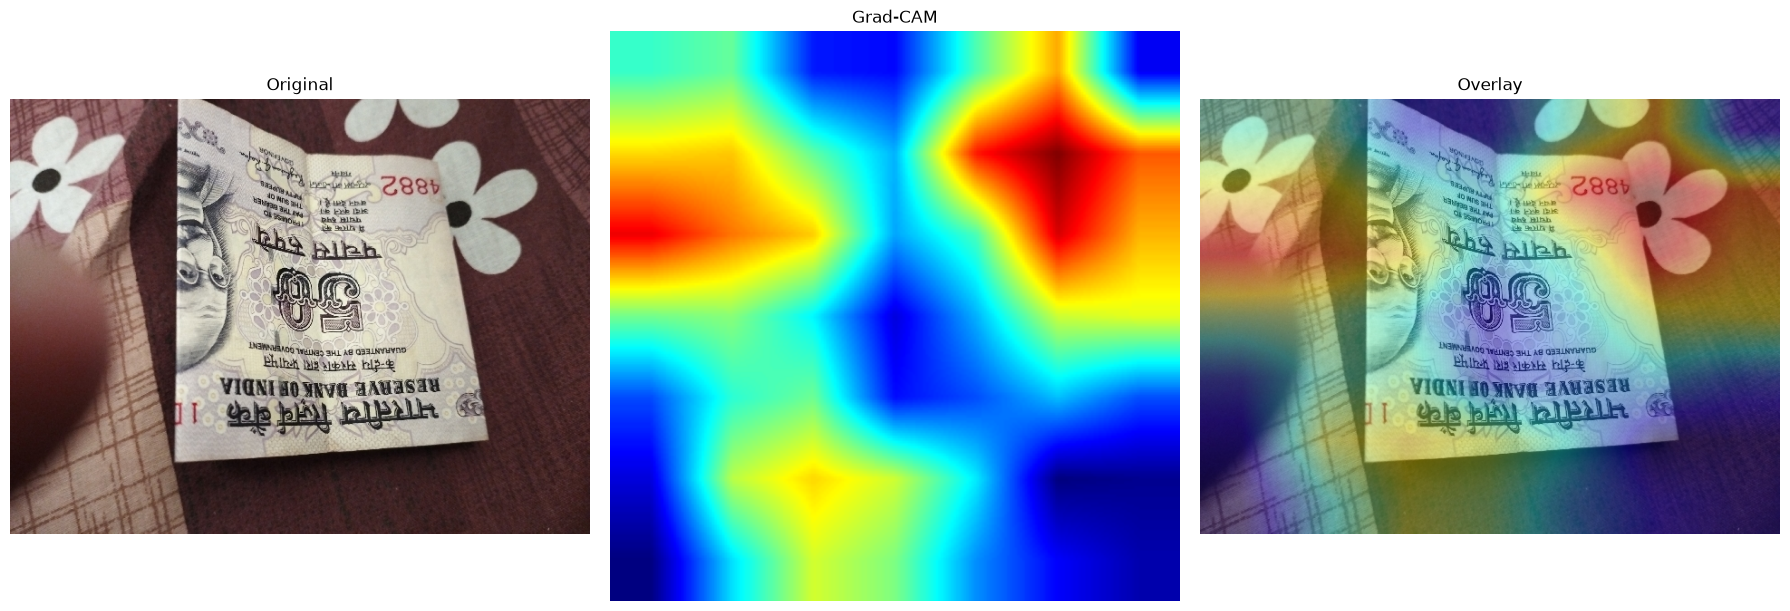

Image        : IMG_1667886981811.jpg
Ground Truth : real
Prediction   : real
Confidence   : 93.35%

Interpretation Guide
-----------------------------
✓ Security Thread
✓ Watermark
✓ Gandhi Portrait
✓ Numerals
✓ Entire Note Body
✗ Background
✗ Hand/Finger
✗ Table/Floor


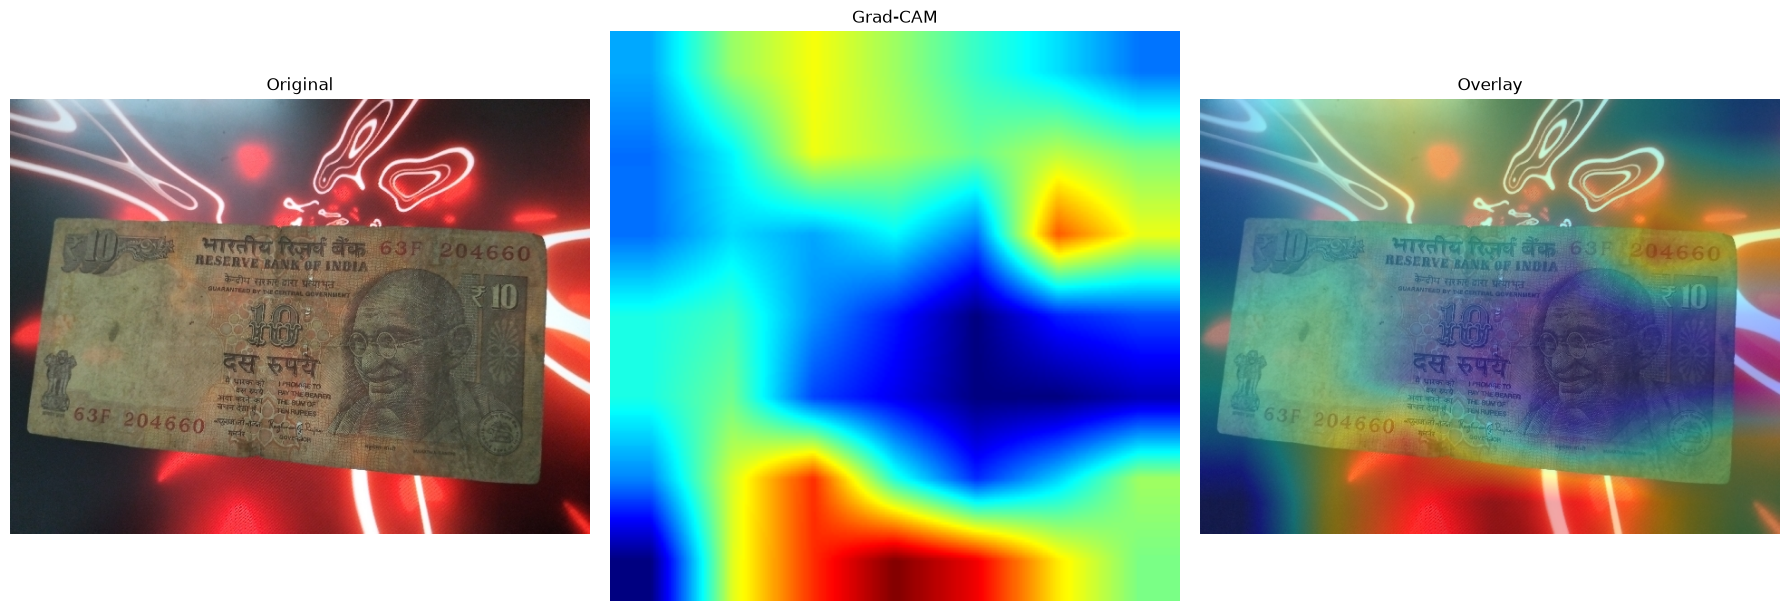

Image        : IMG_1667843250754.jpg
Ground Truth : real
Prediction   : real
Confidence   : 87.72%

Interpretation Guide
-----------------------------
✓ Security Thread
✓ Watermark
✓ Gandhi Portrait
✓ Numerals
✓ Entire Note Body
✗ Background
✗ Hand/Finger
✗ Table/Floor


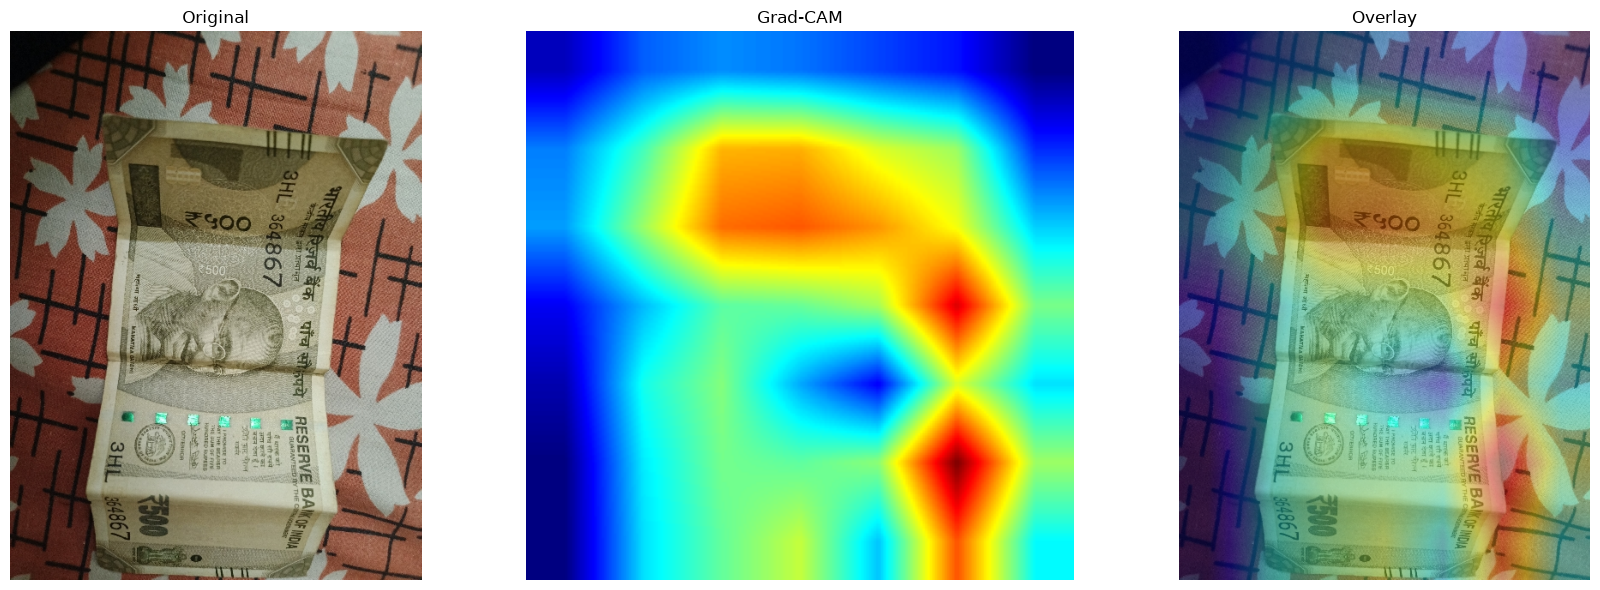

Image        : IMG_1667891131900.jpg
Ground Truth : real
Prediction   : real
Confidence   : 93.02%

Interpretation Guide
-----------------------------
✓ Security Thread
✓ Watermark
✓ Gandhi Portrait
✓ Numerals
✓ Entire Note Body
✗ Background
✗ Hand/Finger
✗ Table/Floor


In [32]:
# ============================================================
# Correct REAL Images
# ============================================================

for i, (img_path, _) in enumerate(correct_real, start=1):

    visualize_and_save(
        img_path,
        ground_truth=1,
        use_ground_truth=False,
        save_name=f"correct_real_{i}"
    )

In [33]:
# ============================================================
# Cleanup
# ============================================================

gradcam.remove()

print("✅ Grad-CAM hooks removed.")
print("✅ Notebook completed successfully.")
print("📁 Results saved to:", OUTPUT_DIR)

✅ Grad-CAM hooks removed.
✅ Notebook completed successfully.
📁 Results saved to: c:\Users\ANKIT\Desktop\SentinelAi\datasets\currency\gradcam_results
